**Step # 01 Clone the Depth Pro Github Repo**

In [1]:
!git clone https://github.com/apple/ml-depth-pro.git

Cloning into 'ml-depth-pro'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 45 (delta 7), reused 2 (delta 2), pack-reused 22 (from 1)
Receiving objects: 100% (45/45), 2.50 MiB | 5.97 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [2]:
%cd /content/ml-depth-pro

/content/ml-depth-pro


**Step # 02 Install All the Required Packages**

In [3]:
!pip install -e .

Obtaining file:///content/ml-depth-pro
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.6 MB/s eta 0:00:00
  Building editable for depth_pro (pyproject.toml) ... done
  Created wheel for depth_pro: filename=depth_pro-0.1-0.editable-py3-none-any.whl size=4775 sha256=4ab060e57f83219e75b1e18976be47d125132214b66ae7ac801268a4eb33804b
  Stored in directory: /tmp/pip-ephem-wheel-cache-x7zmak2n/wheels/4a/c8/e8/cc1a32e9955f99baa359695f0111c5d82c97e9c7c826c0fd7a
Successfully built depth_pro


**Step # 03 Download Depth Pro Model Weights**

In [4]:
!source get_pretrained_models.sh

--2024-12-19 08:16:27--  https://ml-site.cdn-apple.com/models/depth-pro/depth_pro.pt
Resolving ml-site.cdn-apple.com (ml-site.cdn-apple.com)... 17.253.83.195, 17.253.83.201, 2620:149:a21:f000::203, ...
Connecting to ml-site.cdn-apple.com (ml-site.cdn-apple.com)|17.253.83.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1904446787 (1.8G) [binary/octet-stream]
Saving to: ‘checkpoints/depth_pro.pt’

depth_pro.pt        100%[===================>]   1.77G  47.3MB/s    in 40s     

2024-12-19 08:17:08 (45.2 MB/s) - ‘checkpoints/depth_pro.pt’ saved [1904446787/1904446787]



**Check the Available Options**

In [5]:
!depth-pro-run -h

usage: depth-pro-run [-h] [-i IMAGE_PATH] [-o OUTPUT_PATH] [--skip-display] [-v]

Inference scripts of DepthPro with PyTorch models.

options:
  -h, --help            show this help message and exit
  -i IMAGE_PATH, --image-path IMAGE_PATH
                        Path to input image.
  -o OUTPUT_PATH, --output-path OUTPUT_PATH
                        Path to store output files.
  --skip-display        Skip matplotlib display.
  -v, --verbose         Show verbose output.


**Download Images from Drive into Google Colab Notebook**

In [6]:
!pwd

/content/ml-depth-pro


In [7]:
!gdown "https://drive.google.com/uc?id=1-PNmddR4WWc2sJSRpdAmD7hnPqb7e5w4&confirm=t" -O "Images/"

Downloading...
From: https://drive.google.com/uc?id=1-PNmddR4WWc2sJSRpdAmD7hnPqb7e5w4&confirm=t
To: /content/ml-depth-pro/Images/image1.jpeg
100% 190k/190k [00:00<00:00, 4.35MB/s]


In [8]:
!gdown "https://drive.google.com/uc?id=1XxjV5f0YBakvj2FpUaDG063htonnPS1I&confirm=t" -O "Images/"

Downloading...
From: https://drive.google.com/uc?id=1XxjV5f0YBakvj2FpUaDG063htonnPS1I&confirm=t
To: /content/ml-depth-pro/Images/image2.jpeg
100% 191k/191k [00:00<00:00, 4.28MB/s]


In [9]:
!gdown "https://drive.google.com/uc?id=14Vx5L5_Sfa41ilwg_CXLsBQcDhIG2GUe&confirm=t" -O "Images/"

Downloading...
From: https://drive.google.com/uc?id=14Vx5L5_Sfa41ilwg_CXLsBQcDhIG2GUe&confirm=t
To: /content/ml-depth-pro/Images/image3.jpg
100% 148k/148k [00:00<00:00, 3.81MB/s]


**Step # 04 Run Predictions with Depth Pro**

In [10]:
!depth-pro-run -i "Images/" -o ./output/

/content/ml-depth-pro/src/depth_pro/depth_pro.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(config.checkpoint_uri, map_location="cpu")
3it [0

In [11]:
from PIL import Image

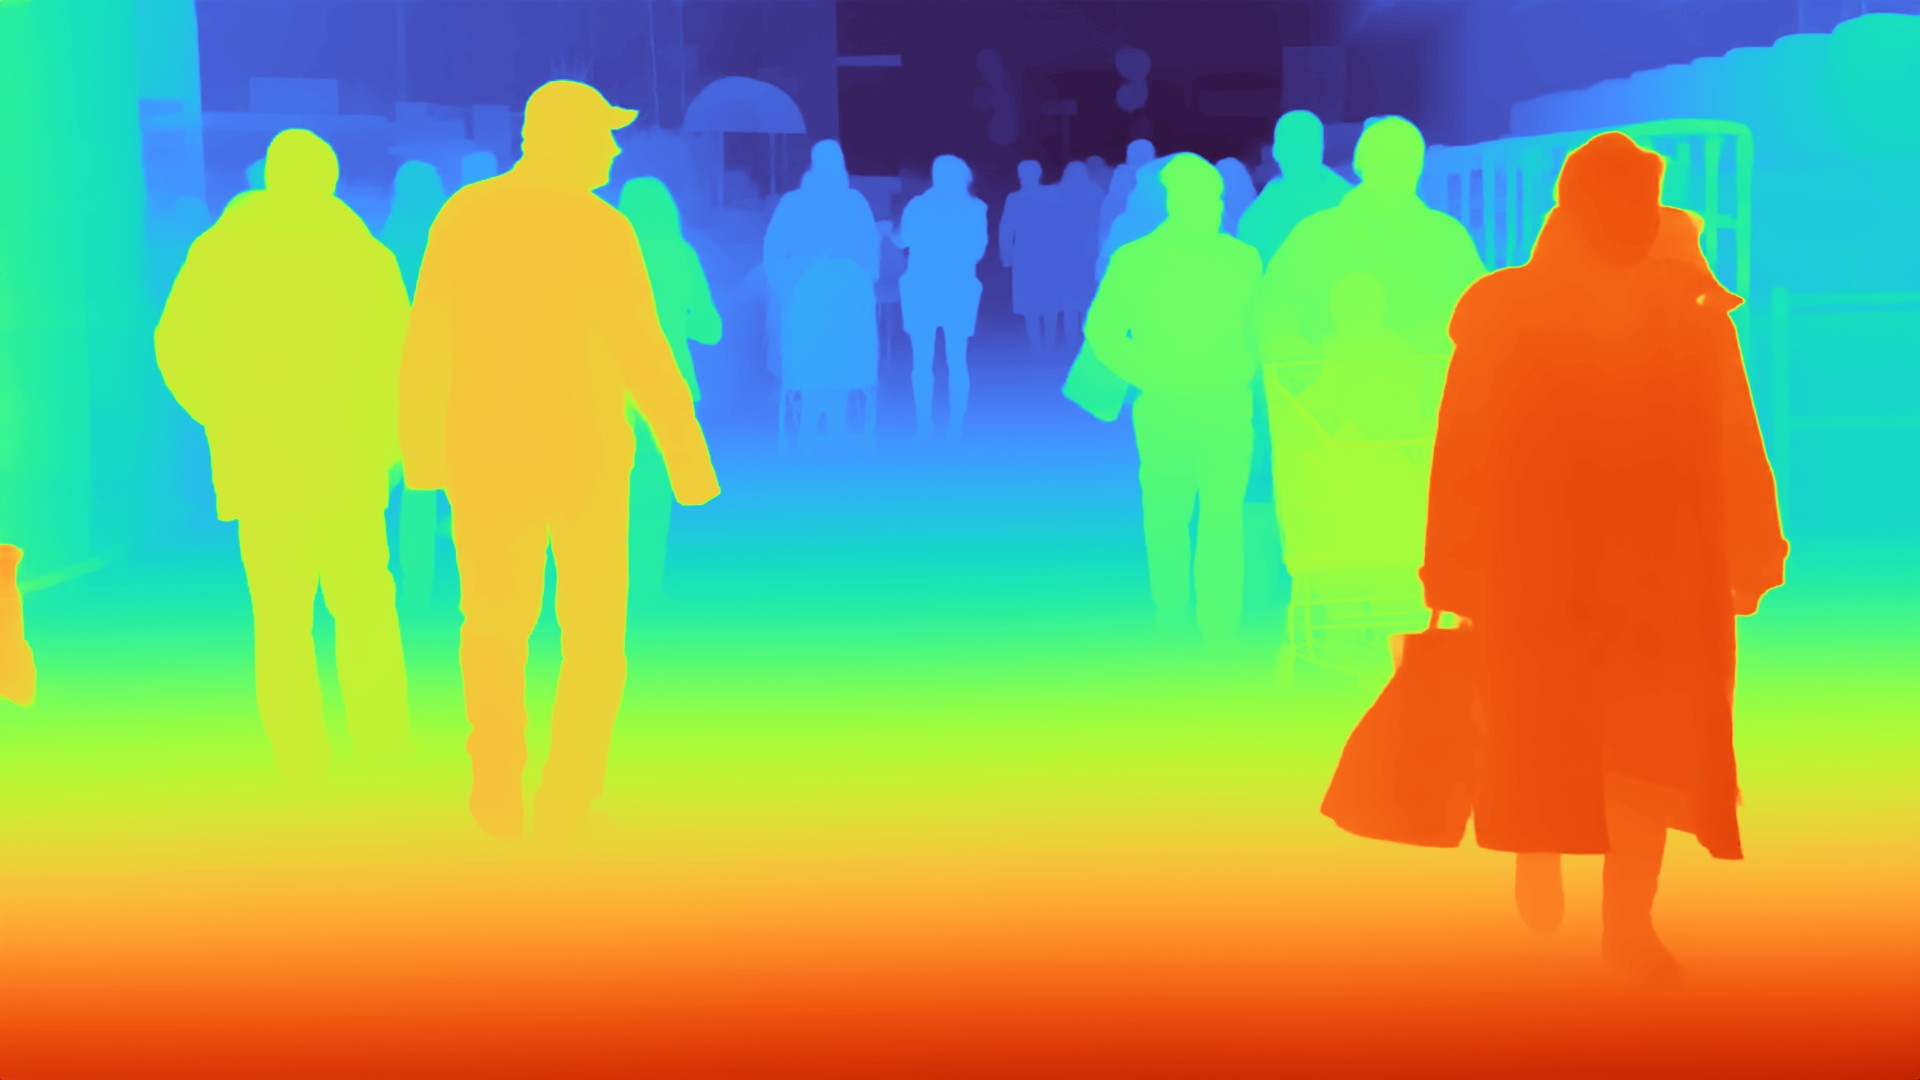

In [12]:
Image.open("/content/ml-depth-pro/output/image1.jpg")

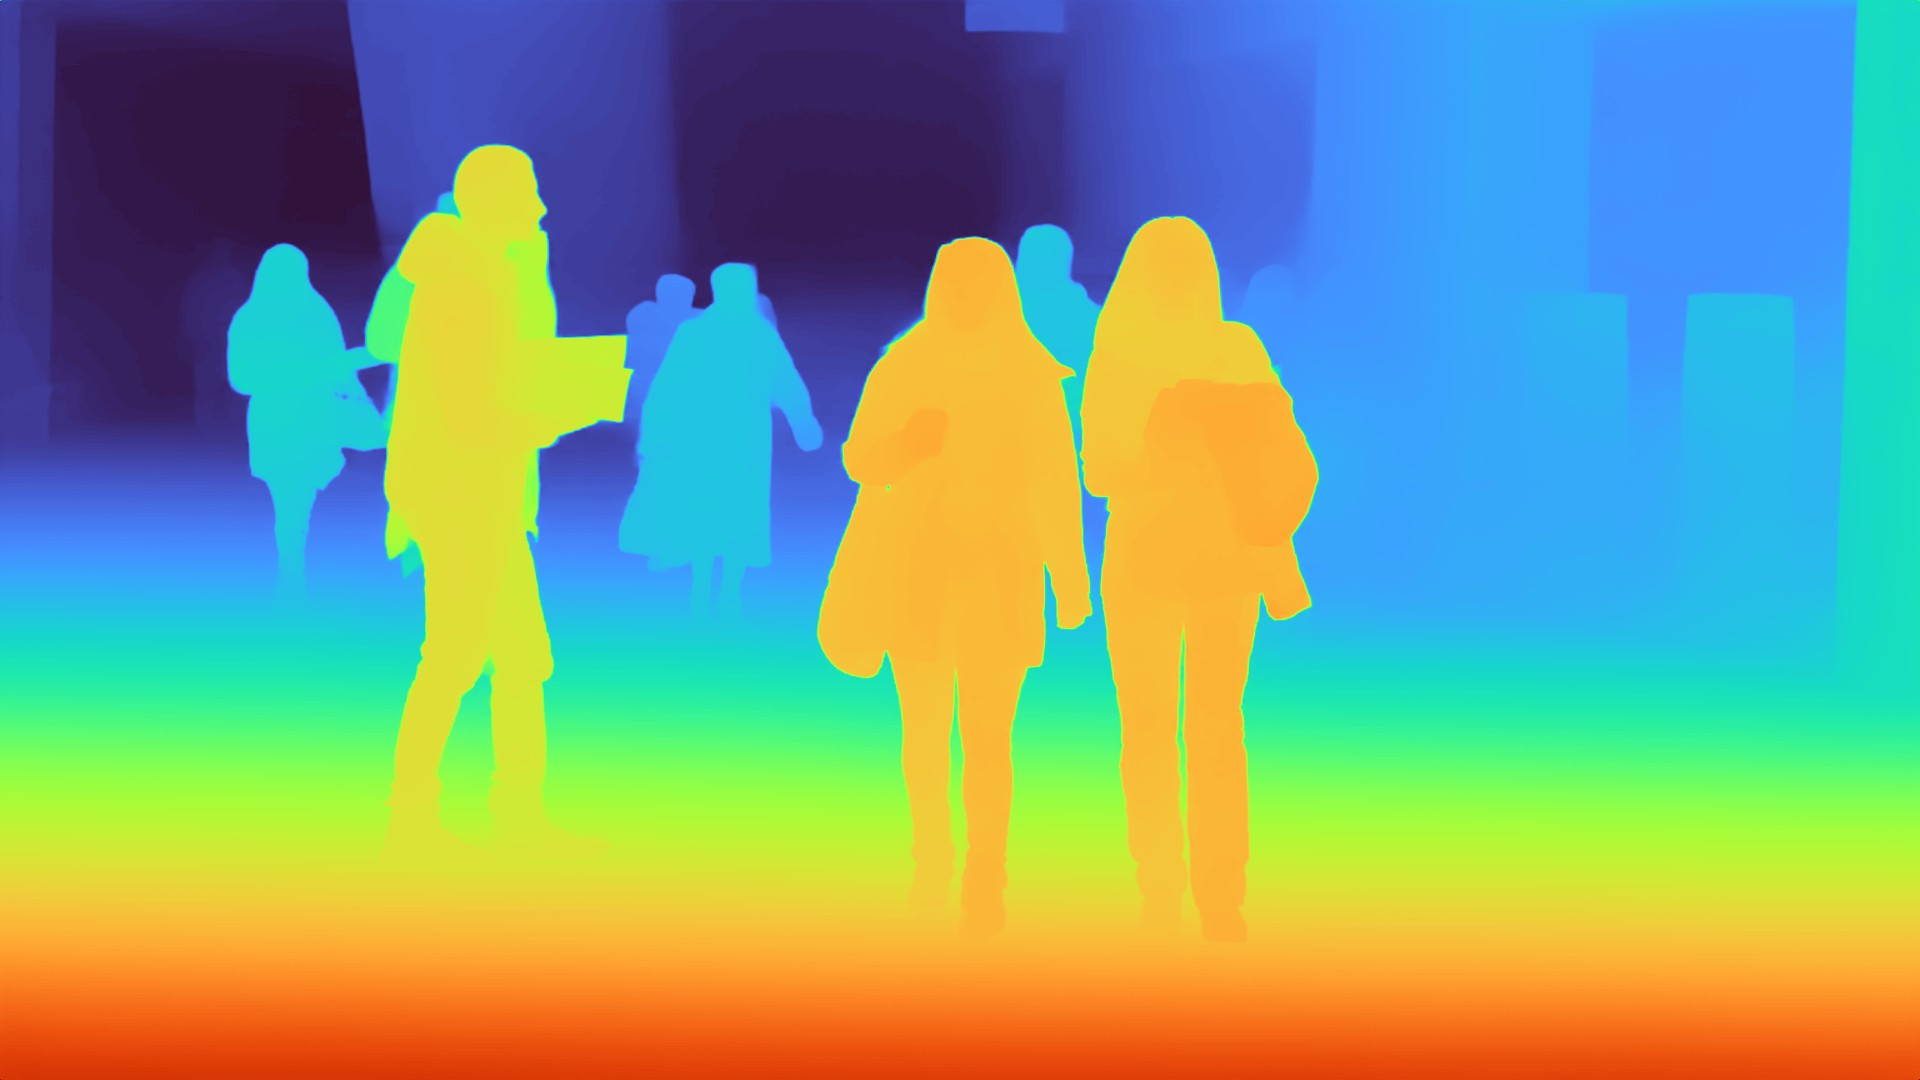

In [13]:
Image.open("/content/ml-depth-pro/output/image2.jpg")

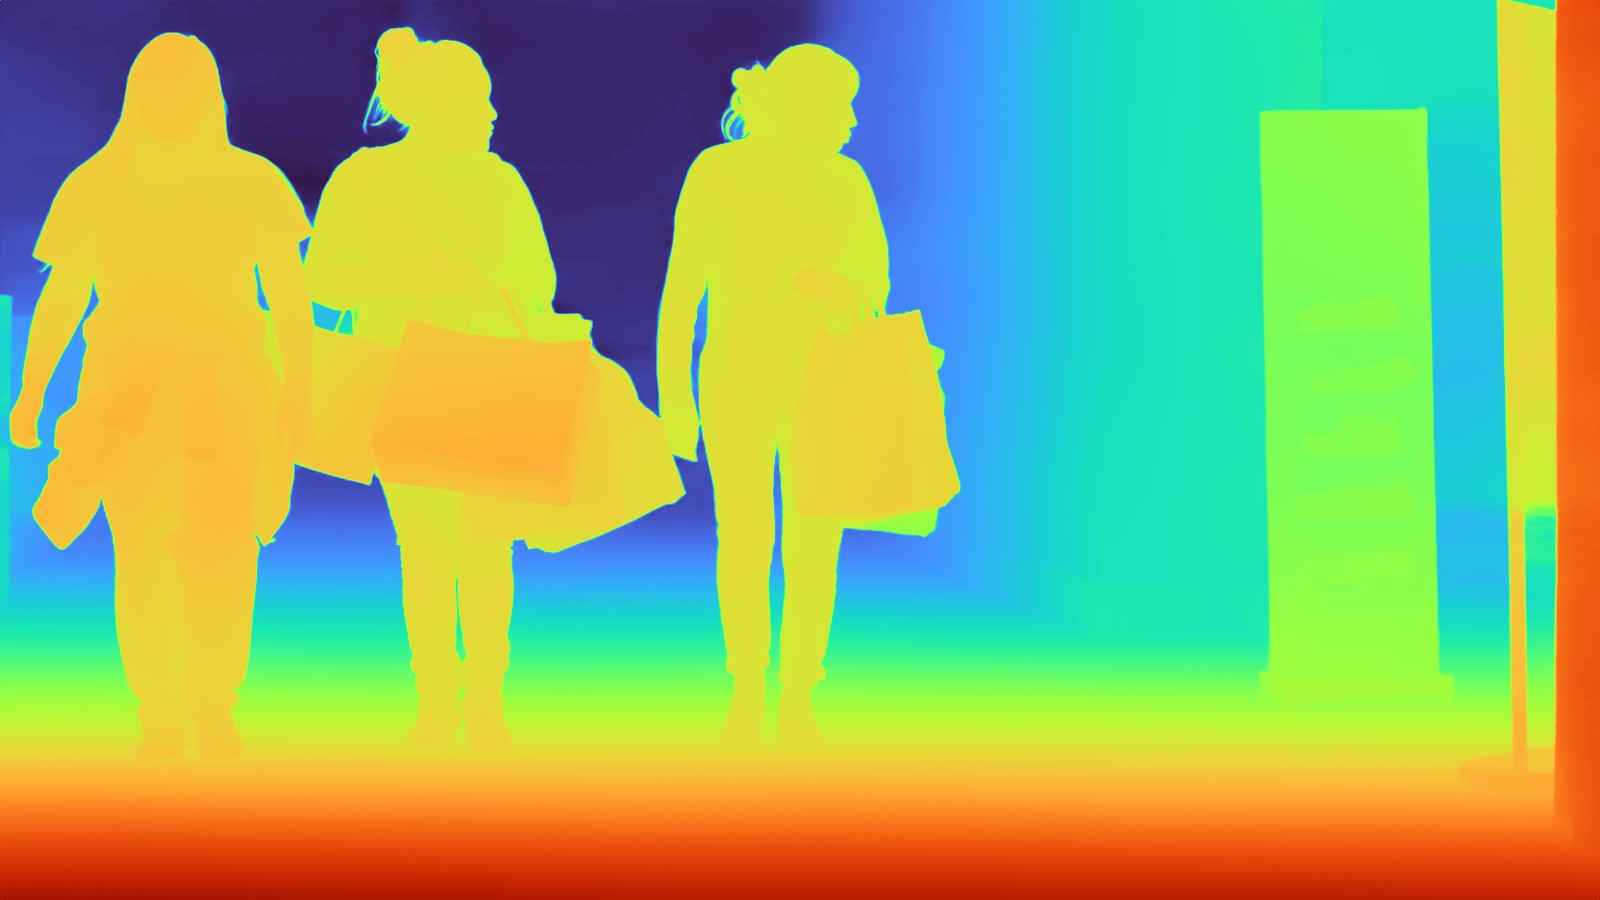

In [14]:
Image.open("/content/ml-depth-pro/output/image3.jpg")

**Estimate Real Distance to Objects with Depth Pro and YOLO11**

**Install All the Required Packages**

In [15]:
!pip install ultralytics
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.3/901.3 kB 22.3 MB/s eta 0:00:00


In [16]:
!gdown "https://drive.google.com/uc?id=1EOz41Ozl-jPZzLKdusziz9wRl6X4DI4Q&confirm=t"

Downloading...
From: https://drive.google.com/uc?id=1EOz41Ozl-jPZzLKdusziz9wRl6X4DI4Q&confirm=t
To: /content/ml-depth-pro/depth_test.py
100% 2.26k/2.26k [00:00<00:00, 12.0MB/s]


In [17]:
!python depth_test.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 18.4M/18.4M [00:00<00:00, 126MB/s] 

0: 384x640 14 persons, 1 handbag, 47.6ms
Speed: 12.5ms preprocess, 47.6ms inference, 759.8ms postprocess per image at shape (1, 3, 384, 640)
<PIL.Image.Image image mode=RGB size=1920x1080 at 0x7A7F54298D30>
<PIL.Image.Image image mode=RGB size=1920x1080 at 0x7A7F54298D30>


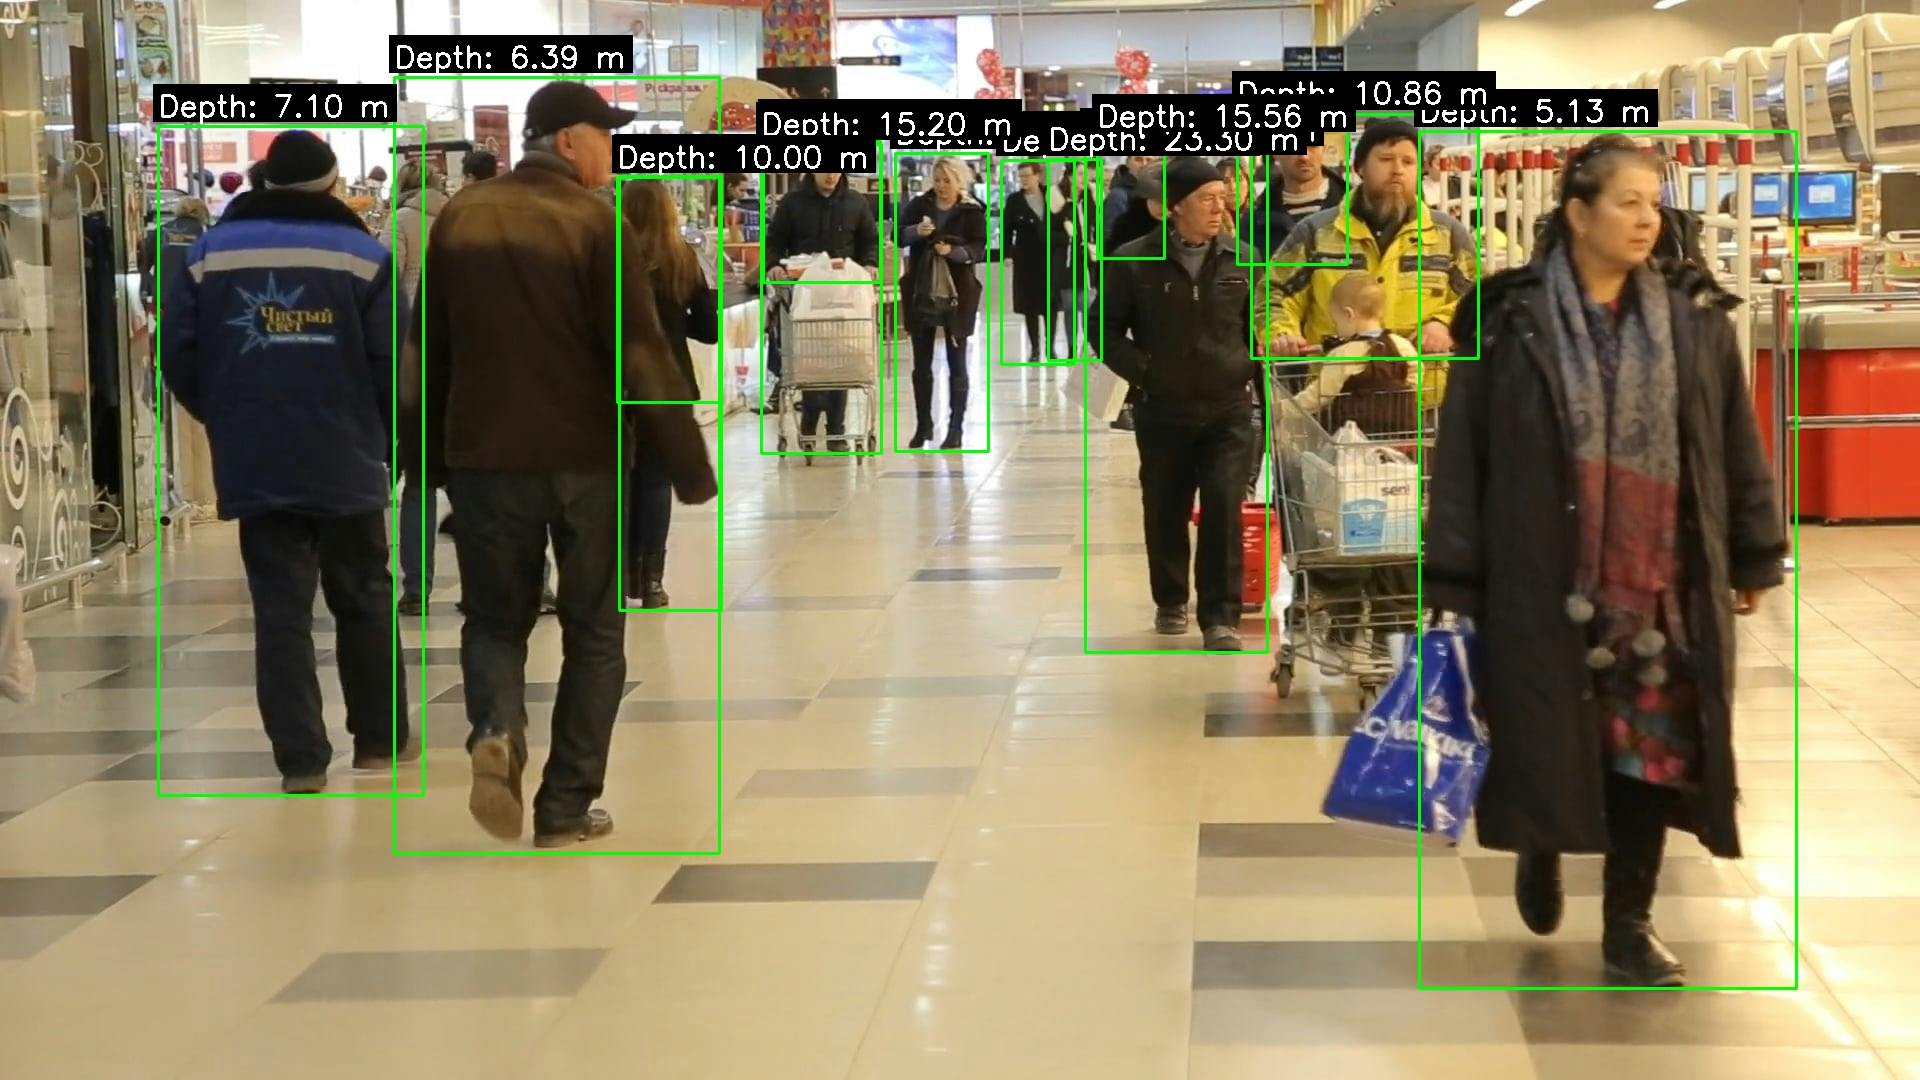

In [19]:
Image.open("/content/ml-depth-pro/depth.jpg")

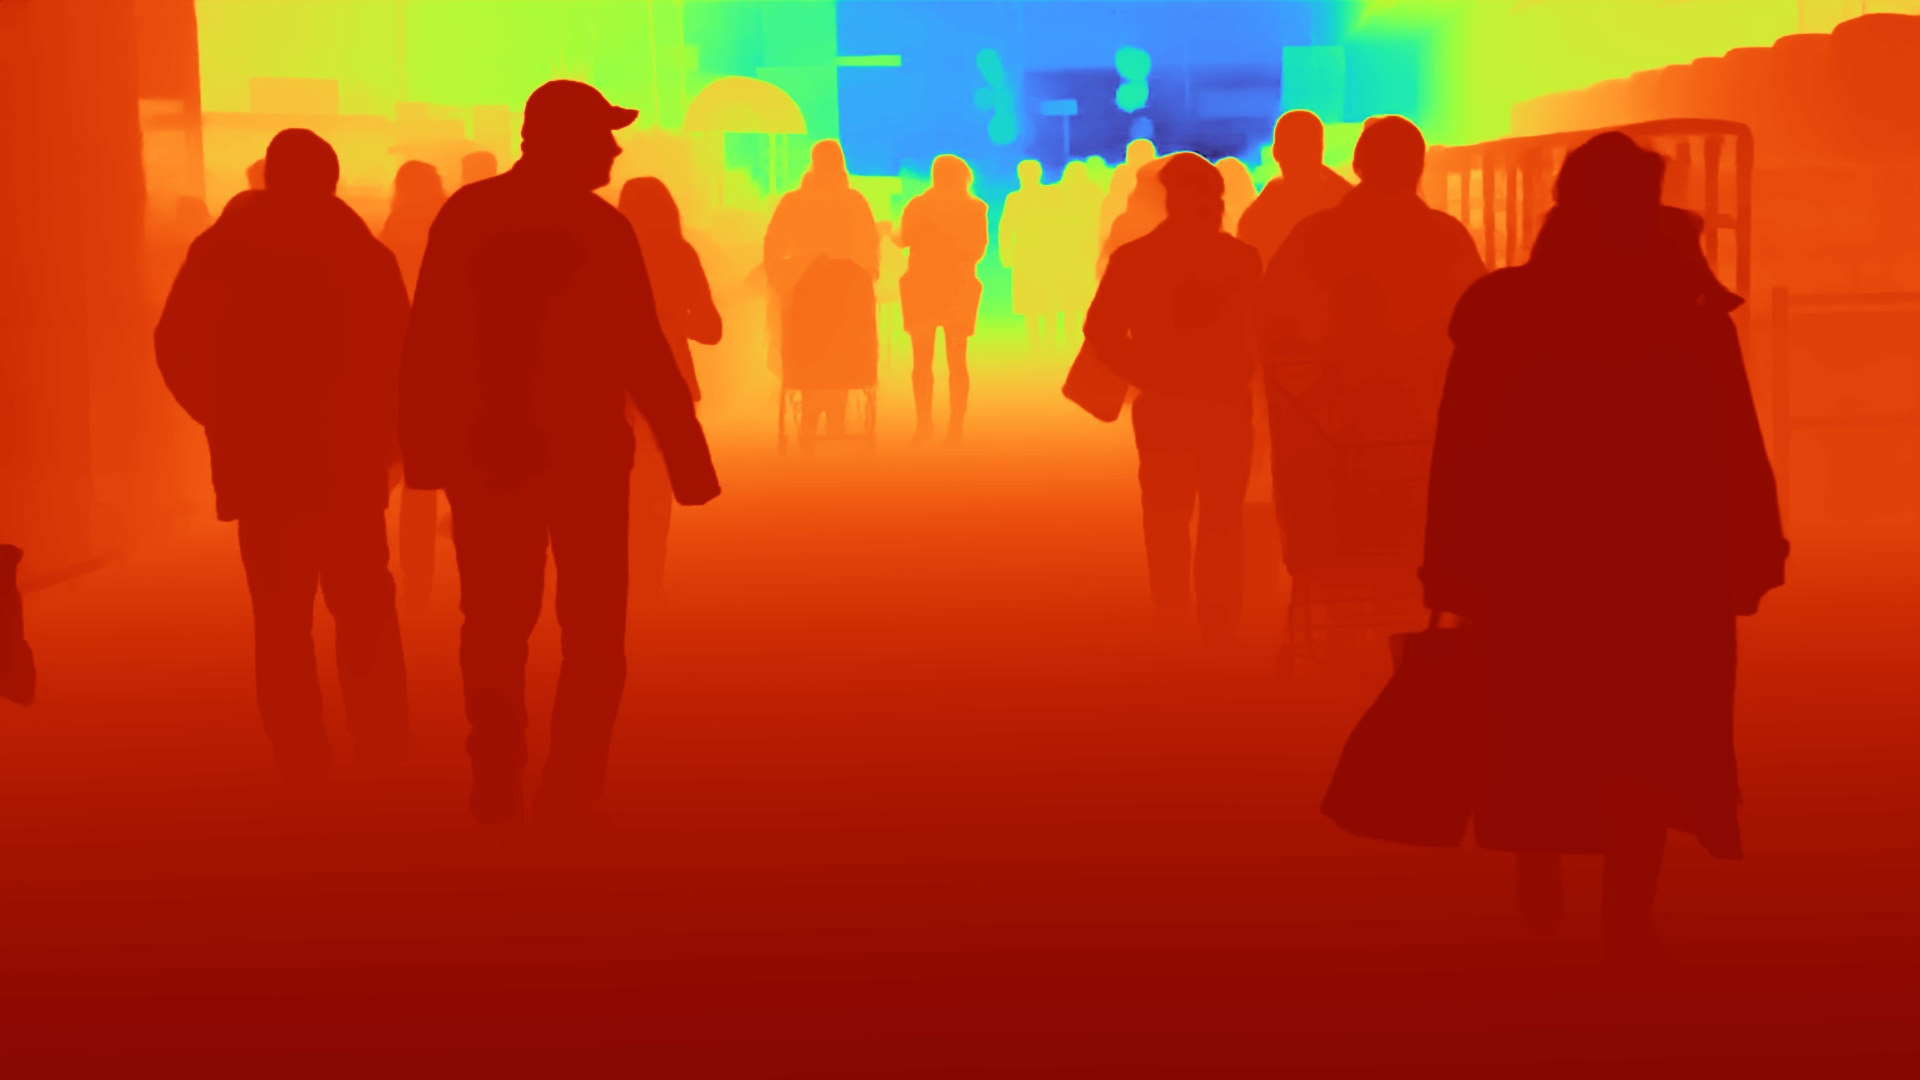

In [20]:
Image.open("/content/ml-depth-pro/depth_colormap.jpg")